✅ Data Loaded Successfully!
  CustomerID  Gender  Age    ContractType  MonthlyCharges  TotalCharges  \
0   CUST1000    Male   44  Month-to-Month           64.03       5935.91   
1   CUST1001  Female   26        Two year           81.53        208.59   
2   CUST1002    Male   50  Month-to-Month           28.35       2062.17   
3   CUST1003    Male   37  Month-to-Month          108.24       1793.81   
4   CUST1004    Male   30        Two year          100.36       2239.37   

   CustomerServiceCalls Churn  
0                     9    No  
1                     5    No  
2                     7    No  
3                     5    No  
4                     3    No  

Missing Values in Each Column:
CustomerID              0
Gender                  0
Age                     0
ContractType            0
MonthlyCharges          0
TotalCharges            0
CustomerServiceCalls    0
Churn                   0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_26084\3961213456.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


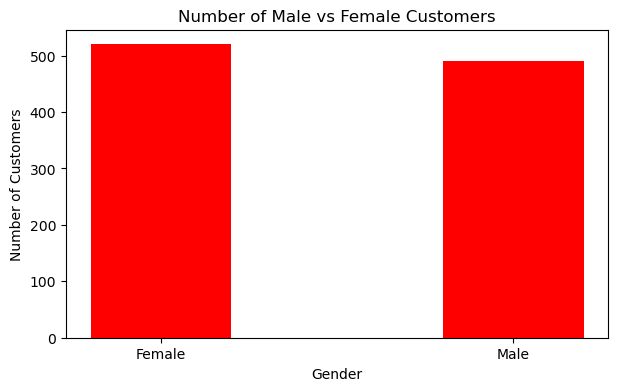

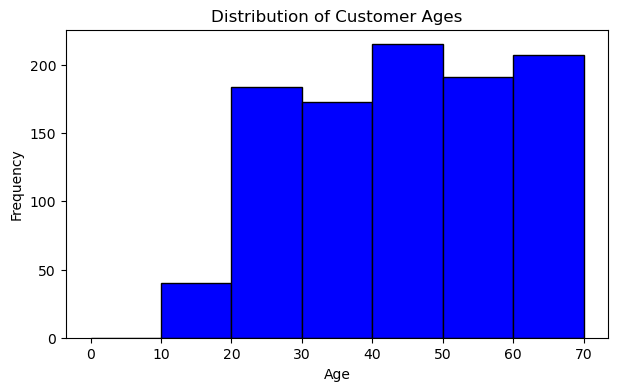

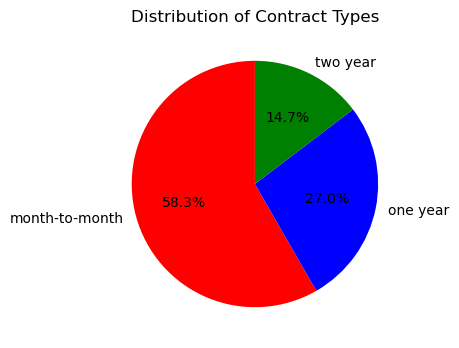


✅ Final Feature Columns Used:
['Gender', 'Age', 'MonthlyCharges', 'TotalCharges', 'CustomerServiceCalls', 'ContractType_month-to-month', 'ContractType_one year', 'ContractType_two year']


C:\Users\HP\AppData\Local\Temp\ipykernel_26084\3961213456.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\HP\AppData\Local\Temp\ipykernel_26084\3961213456.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


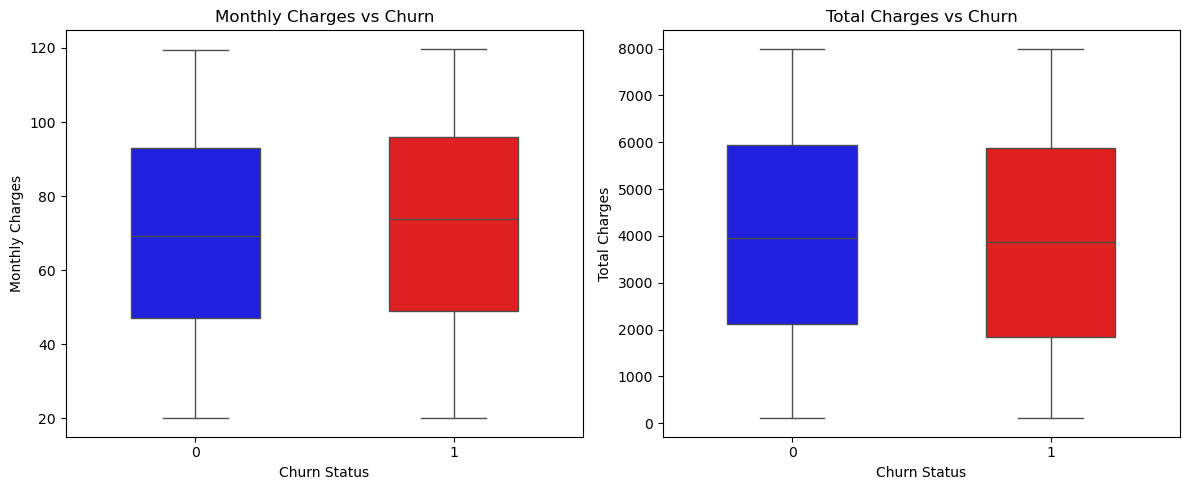

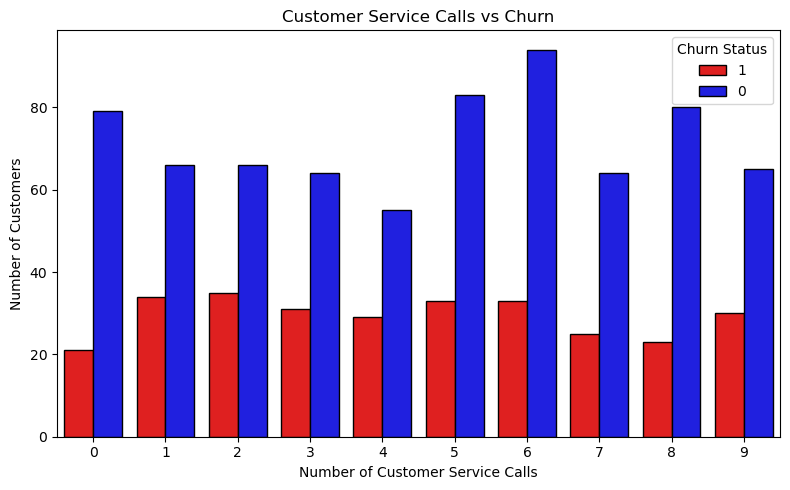


📈 Model Evaluation:
Accuracy: 0.6237623762376238

Confusion Matrix:
 [[109  28]
 [ 48  17]]

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.80      0.74       137
           1       0.38      0.26      0.31        65

    accuracy                           0.62       202
   macro avg       0.54      0.53      0.53       202
weighted avg       0.59      0.62      0.60       202


--- 🔮 New Customer Churn Prediction ---


Enter Gender (Male/Female):  Male
Enter Customer Age:  2
Enter Monthly Charges:  45
Enter Total Charges:  5678
Enter Total Customer Service Calls:  5
Enter Contract Type (Month-to-month/One year/Two year):  One year



===== Prediction Result =====
Prediction: ✅ Customer is likely to Stay
Probability of Staying: 0.67
Probability of Churning: 0.33


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


In [6]:
# ===============================================
# 📊 Customer Churn Prediction using KNN
# ===============================================

# ---- Import Required Libraries ----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---- Load Dataset ----
df = pd.read_csv("CustomerChurnPred.csv")
print("✅ Data Loaded Successfully!")
print(df.head())

# ---- Check for Null Values ----
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

# ==================================================
# 🔍 Data Preprocessing
# ==================================================

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

# Encode target column: Churn -> 0/1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Normalize ContractType for consistent encoding
df['ContractType'] = df['ContractType'].str.strip().str.lower()

# ==================================================
# 🔍 Exploratory Data Analysis (EDA)
# ==================================================

# Gender Distribution
plt.figure(figsize=(7,4))
gender_count = df['Gender'].value_counts()
plt.bar(gender_count.index, gender_count.values, color='r', width=0.4)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.title("Number of Male vs Female Customers")
plt.show()

# Age Distribution
Tot_bins = [0,10,20,30,40,50,60,70]
plt.figure(figsize=(7,4))
plt.hist(df['Age'], bins=Tot_bins, color='blue', edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Ages")
plt.show()

# Pie chart: Contract type distribution (before dropping column)
plt.figure(figsize=(7,4))
plt.pie(
    x=df['ContractType'].value_counts(),
    labels=df['ContractType'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['red', 'blue', 'green']
)
plt.title("Distribution of Contract Types")
plt.show()

# ==================================================
# 🧩 Data Encoding
# ==================================================

# Label Encoding for Gender
Le = LabelEncoder()
df['Gender'] = Le.fit_transform(df['Gender'])

# OneHotEncoding for ContractType with safe handling of unknown categories
ohe = OneHotEncoder(drop=None, sparse_output=False, handle_unknown='ignore')
encoded = ohe.fit_transform(df[['ContractType']])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(['ContractType']))

# Merge encoded columns and drop original
df = pd.concat([df, encoded_df], axis=1)
df.drop(columns=['ContractType'], inplace=True)

# Features and Target
feature_cols = ['Gender', 'Age', 'MonthlyCharges', 'TotalCharges', 'CustomerServiceCalls'] + list(encoded_df.columns)
X = df[feature_cols]
y = df['Churn']

print("\n✅ Final Feature Columns Used:")
print(X.columns.tolist())

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================================================
# 🔍 EDA continued: Boxplots and Countplots
# ==================================================

# Boxplots: MonthlyCharges and TotalCharges vs Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    x=df['Churn'].astype(str), 
    y='MonthlyCharges', 
    data=df,
    palette={'0': 'blue', '1': 'red'},
    width=0.5, ax=axes[0]
)
axes[0].set_title('Monthly Charges vs Churn')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Monthly Charges')

sns.boxplot(
    x=df['Churn'].astype(str), 
    y='TotalCharges', 
    data=df,
    palette={'0': 'blue', '1': 'red'},
    width=0.5, ax=axes[1]
)
axes[1].set_title('Total Charges vs Churn')
axes[1].set_xlabel('Churn Status')
axes[1].set_ylabel('Total Charges')

plt.tight_layout()
plt.show()

# Countplot: Customer Service Calls vs Churn
plt.figure(figsize=(8,5))
sns.countplot(
    x='CustomerServiceCalls', hue=df['Churn'].astype(str), data=df,
    palette={'0': 'blue', '1': 'red'}, edgecolor='black'
)
plt.title('Customer Service Calls vs Churn')
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Number of Customers')
plt.legend(title='Churn Status')
plt.tight_layout()
plt.show()

# ==================================================
# 🤖 Model Training using KNN
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Predict on Test Data
y_pred = model.predict(X_test)
# Evaluation
print("\n📈 Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
# ==================================================
# 🧮 Predict Churn for a New Customer
# ==================================================
print("\n--- 🔮 New Customer Churn Prediction ---")
# User input
gender = input("Enter Gender (Male/Female): ").title()
age = int(input("Enter Customer Age: "))
monthly_charges = float(input("Enter Monthly Charges: "))
total_charges = float(input("Enter Total Charges: "))
customer_calls = int(input("Enter Total Customer Service Calls: "))
contract_type = input("Enter Contract Type (Month-to-month/One year/Two year): ").strip().lower()
# Encode gender safely
try:
    gender_encoded = Le.transform([gender])[0]
except:
    print("⚠️ Invalid Gender input. Using default 'Male'.")
    gender_encoded = Le.transform(['Male'])[0]
# Encode contract safely
encoded_contract = ohe.transform([[contract_type]])
encoded_contract_df = pd.DataFrame(encoded_contract, columns=ohe.get_feature_names_out(['ContractType']))
# Combine into single DataFrame
new_customer = pd.DataFrame({
    'Gender': [gender_encoded],
    'Age': [age],
    'MonthlyCharges': [monthly_charges],
    'TotalCharges': [total_charges],
    'CustomerServiceCalls': [customer_calls]
})
new_customer = pd.concat([new_customer, encoded_contract_df], axis=1)
# Ensure same column order as training data
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)
# Scale new customer
new_customer_scaled = scaler.transform(new_customer)
# Make prediction
prediction = model.predict(new_customer_scaled)[0]
probabilities = model.predict_proba(new_customer_scaled)[0]
# Interpret results
status = "❌ Customer is likely to Churn" if prediction == 1 else "✅ Customer is likely to Stay"
print("\n===== Prediction Result =====")
print(f"Prediction: {status}")
print(f"Probability of Staying: {probabilities[0]:.2f}")
print(f"Probability of Churning: {probabilities[1]:.2f}")
print("==============================")
